<p align="center">
  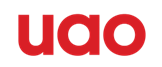
</p>

<center> <h1>LABORATORIO No 1 - ETL</h1> </center>
<center>============================================================</center>

# INTEGRANTES

**Nombre:** Roberto José Guerrero Criollo  
*Correo:* roberto_jos.guerrero@uao.edu.co  
   
**Nombre:** Melissa Muñoz Buitron  
*Correo:* melissa.munoz@uao.edu.co

In [12]:
import sys
!{sys.executable} -m pip uninstall prefect -y


Found existing installation: prefect 3.6.23
Uninstalling prefect-3.6.23:
  Successfully uninstalled prefect-3.6.23


In [13]:
!{sys.executable} -m pip install prefect

  Using cached prefect-3.6.23-py3-none-any.whl.metadata (13 kB)
Using cached prefect-3.6.23-py3-none-any.whl (11.8 MB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import prefect
print(prefect.__version__)
print(dir(prefect))

3.6.23
['Any', 'Optional', 'TYPE_CHECKING', 'TypedDict', '__all__', '__annotations__', '__builtins__', '__cached__', '__development_base_path__', '__doc__', '__file__', '__getattr__', '__loader__', '__module_path__', '__name__', '__package__', '__path__', '__spec__', '__ui_static_path__', '__ui_static_subpath__', '__ui_v2_static_path__', '__ui_v2_static_subpath__', '__version__', '__version_info__', '_experimental', '_initialize_plugins', '_initialize_sdk_analytics', '_internal', '_public_api', '_result_records', '_versioning', '_waiters', 'assets', 'blocks', 'cast', 'client', 'context', 'events', 'exceptions', 'filesystems', 'flows', 'futures', 'importlib', 'locking', 'logging', 'plugins', 'results', 'schedules', 'serializers', 'settings', 'states', 'sys', 'task_runners', 'task_runs', 'types', 'utilities']


# PIPELINE DEL PROCESO DE ETL

In [11]:

from prefect import flow, task
import pandas as pd
import sqlite3
from scipy.stats import mstats

# ── EXTRACT ──────────────────────────────────────────────────
@task
def extract_data():
    df = pd.read_csv("lab2_trial_conversion_users.csv")
    print(f"Datos extraídos: {df.shape[0]} registros, {df.shape[1]} columnas")
    return df

# ── TRANSFORM ────────────────────────────────────────────────
@task
def transform_data(df):
    # 1. Eliminar duplicados
    df = df.drop_duplicates(subset="user_id", keep="first")

    # 2. Normalizar fechas
    for col in ["signup_date", "trial_end_date"]:
        df[col] = pd.to_datetime(df[col], format="mixed", dayfirst=True).dt.strftime("%d/%m/%Y")

    # 3. Normalizar categóricas
    for col in ["country", "gender", "device_type", "acquisition_channel",
                "city_tier", "preferred_plan_before_conversion", "selected_plan"]:
        df[col] = df[col].str.strip().str.title()

    # 4. Limpiar símbolos en numéricas
    df["monthly_income_usd"] = pd.to_numeric(
        df["monthly_income_usd"].astype(str).str.replace("$", "", regex=False), errors="coerce"
    )
    df["discount_offered_pct"] = pd.to_numeric(
        df["discount_offered_pct"].astype(str).str.replace("%", "", regex=False), errors="coerce"
    )

    # 5. Winsorization avg_session_minutes
    df["avg_session_minutes"] = mstats.winsorize(
        df["avg_session_minutes"], limits=[0, 0.05]
    )

    # 6. Imputar nulos
    df["age"] = df["age"].fillna("No registra")
    df["country"] = df["country"].fillna("No registra")
    df["device_type"] = df["device_type"].fillna("No registra")
    df["avg_session_minutes"] = df["avg_session_minutes"].fillna(df["avg_session_minutes"].median())
    df["satisfaction_score"] = df["satisfaction_score"].fillna(df["satisfaction_score"].median())

    # 7. Encoding
    orden_plan = {"Basic": 1, "Standard": 2, "Premium": 3}
    df["preferred_plan_encoded"] = df["preferred_plan_before_conversion"].map(orden_plan)

    # 8. Feature engineering
    df["minutos_totales"] = df["avg_session_minutes"] * df["sessions_count"]
    df["intensidad_uso"] = df["features_used"] * df["sessions_count"]
    df["engagement_score"] = df["emails_opened"] + df["webinar_attended"] + df["plan_page_views"]
    df["intencion_comercial"] = df["payment_method_on_file"] + df["plan_page_views"] + df["discount_offered_pct"]

    print(f"Transformación completada: {df.shape[0]} registros, {df.shape[1]} columnas")
    return df

# ── LOAD ─────────────────────────────────────────────────────
@task
def load_data(df):
    conn = sqlite3.connect("lab2_etl.db")

    # Tabla dataset limpio
    df.to_sql("usuarios", conn, if_exists="replace", index=False)

    # Tabla modelo_input (X)
    X = df[["user_id", "days_active_trial", "sessions_count", "avg_session_minutes",
            "features_used", "last_activity_gap_days", "satisfaction_score",
            "preferred_plan_encoded", "minutos_totales", "intensidad_uso",
            "engagement_score", "intencion_comercial"]]
    X.to_sql("modelo_input", conn, if_exists="replace", index=False)

    # Tabla variable objetivo (y)
    y = df[["user_id", "converted_to_paid_plan"]]
    y.to_sql("variable_objetivo", conn, if_exists="replace", index=False)

    conn.close()
    print("Datos cargados en SQLite: lab2_etl.db")
    return "Carga completada"

# ── PIPELINE ─────────────────────────────────────────────────
@flow(name="ETL_Lab2_TrialConversion")
def etl_pipeline():
    df_raw = extract_data()
    df_transformado = transform_data(df_raw)
    status = load_data(df_transformado)
    print(status)

# Ejecutar
etl_pipeline()

15:19:41.303 | INFO    | Flow run 'merciful-jaguarundi' - Beginning flow run 'merciful-jaguarundi' for flow 'ETL_Lab2_TrialConversion'

Datos extraídos: 2545 registros, 27 columnas


15:19:42.061 | INFO    | Task run 'extract_data-f97' - Finished in state Completed()

C:\Users\Molly\AppData\Local\Temp\ipykernel_16236\2707654427.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_datetime(df[col], format="mixed", dayfirst=True).dt.strftime("%d/%m/%Y")
C:\Users\Molly\AppData\Local\Temp\ipykernel_16236\2707654427.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = pd.to_datetime(df[col], format="mixed", dayfirst=True).dt.strftime("%d/%m/%Y")
C:\Users\Molly\AppData\Local\Temp\ipykernel_16236\2707654427.py:26: SettingWithCopyWarning: 
A value is tr

Transformación completada: 2500 registros, 32 columnas


...

15:19:42.823 | INFO    | Task run 'transform_data-7f4' - Finished in state Completed()

Datos cargados en SQLite: lab2_etl.db


15:19:43.390 | INFO    | Task run 'load_data-720' - Finished in state Completed()

Carga completada


15:19:43.609 | INFO    | Flow run 'merciful-jaguarundi' - Finished in state Completed()

In [12]:
import sqlite3
import pandas as pd

# Conectar y consultar
conn = sqlite3.connect("lab2_etl.db")

X = pd.read_sql("SELECT * FROM modelo_input", conn)
y = pd.read_sql("SELECT * FROM variable_objetivo", conn)

conn.close()

print("=== TABLA modelo_input ===")
print(X)
print(X.head())

print("\n=== TABLA variable_objetivo ===")
print(y)
print(y.head())

=== TABLA modelo_input ===
        user_id  days_active_trial  sessions_count  avg_session_minutes  \
0     USR-00001                 12              26                  8.5   
1     USR-00002                  8              14                 10.8   
2     USR-00003                  9              10                 13.3   
3     USR-00004                 11              25                 12.5   
4     USR-00005                 10              22                 15.5   
...         ...                ...             ...                  ...   
2495  USR-02496                  8              12                 21.7   
2496  USR-02497                  8              16                 15.7   
2497  USR-02498                 14              22                 15.8   
2498  USR-02499                  8              12                 11.0   
2499  USR-02500                 12              19                 13.3   

      features_used  last_activity_gap_days  satisfaction_score  \
0    

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression

# Quitar user_id
X_model = X.drop(columns=["user_id"])
y_model = y["converted_to_paid_plan"]

# Split
X_train, X_temp, y_train, y_temp = train_test_split(X_model, y_model, test_size=0.4, random_state=42, stratify=y_model)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Escalado
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

# Modelo
modelo = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
modelo.fit(X_train_scaled, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


=== MÉTRICAS EN TEST ===
Accuracy  : 0.6580
Precision : 0.3702
Recall    : 0.6581
F1        : 0.4738
ROC-AUC   : 0.7277

=== MÉTRICAS EN VALIDATION ===
Accuracy  : 0.6640
Precision : 0.3791
Recall    : 0.6838
F1        : 0.4878
ROC-AUC   : 0.7462


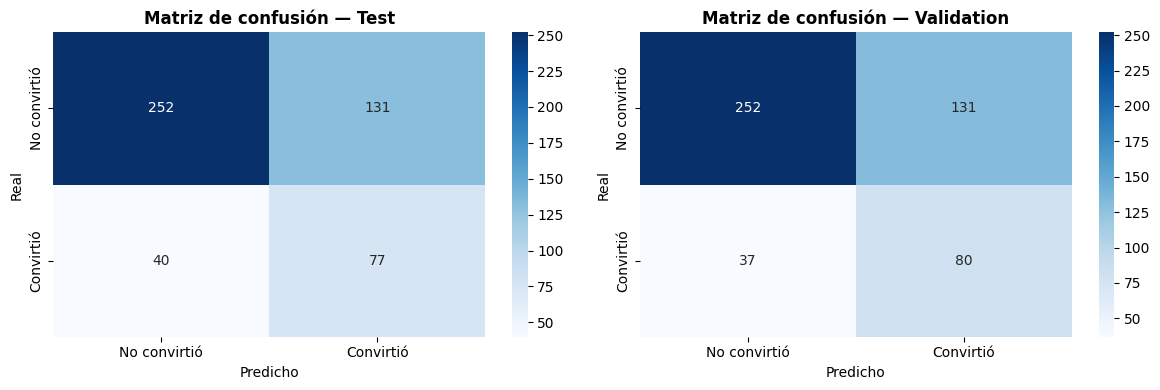

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_pred_test = modelo.predict(X_test_scaled)
y_pred_val = modelo.predict(X_val_scaled)

# Métricas
print("=== MÉTRICAS EN TEST ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_test):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, modelo.predict_proba(X_test_scaled)[:,1]):.4f}")

print("\n=== MÉTRICAS EN VALIDATION ===")
print(f"Accuracy  : {accuracy_score(y_val, y_pred_val):.4f}")
print(f"Precision : {precision_score(y_val, y_pred_val):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred_val):.4f}")
print(f"F1        : {f1_score(y_val, y_pred_val):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_val, modelo.predict_proba(X_val_scaled)[:,1]):.4f}")

# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (y_true, y_pred, titulo) in zip(axes, [
    (y_test, y_pred_test, "Test"),
    (y_val, y_pred_val, "Validation")
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No convirtió", "Convirtió"],
                yticklabels=["No convirtió", "Convirtió"])
    ax.set_title(f"Matriz de confusión — {titulo}", fontweight="bold")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")

plt.tight_layout()
plt.show()